# Linear Regression Project — Boston Housing

**Goal:** Build and analyze a linear regression model to predict median home values (`medv`) using the Boston Housing dataset.

This notebook performs:
- Data loading & inspection  
- Missing-value handling with KNN Imputation (with checks)  
- Exploratory Data Analysis (distributions, correlations, scatter plots)  
- Multicollinearity detection and reduction (VIF)  
- Model building: custom OLS (from-scratch) and scikit-learn comparison  
- Cross-validation and residual diagnostics  
- Clear interpretation and final recommendations

**Note:** This notebook uses a VIF-reduced predictor set for stable inference. If you want to use the full predictor set for pure prediction tasks, mention it in the conclusions.


## Imports & Setup

In [1]:
# Step 0 — Imports and settings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Scikit-learn utilities
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score

# Stats / diagnostics
import statsmodels.api as sm
from scipy import stats

# Rice ML custom modules
from rice_ml.processing.KNN_imputation import knn_impute
from rice_ml.processing.multicollinearity import compute_vif, reduce_multicollinearity
from rice_ml.processing.scaling import StandardScaler
from rice_ml.supervised_learning.linear_regression import LinearRegression

# Plot settings
plt.rcParams["figure.figsize"] = (8, 6)
plt.style.use("seaborn-v0_8")





## Load data

In [2]:
# Step 1 — Load dataset

DATA_PATH = Path("../../../datasets/BostonHousing.csv")

# Check that data is available
assert os.path.exists(DATA_PATH), (
    f"Dataset not found at {DATA_PATH}. "
    "Make sure datasets/BostonHousing.csv exists relative to this notebook."
)

# Read dataset
df = pd.read_csv(DATA_PATH)

# Standardize column names
df.columns = df.columns.str.lower()

# Preview data
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


##### __Variables:__
- **__crim__**: Per capita crime rate by town. A measure of local crime and safety.

- **__zn__**: Proportion of large residential lots (over 25,000 sq. ft.). Indicates the amount of low-density, potentially wealthier residential land.

- **__indus__**: Proportion of non-retail business acres per town. A measure of industrialization in the area.

- **__chas__**: Binary variable indicating if the property is near Charles River (1 for yes, 0 for no). A premium factor; homes bordering the river are often more desirable.

- **__nox__**: Concentration of nitrogen oxides in the air. A measure of air pollution.

- **__rm__**: Average number of rooms per dwelling. A strong proxy for the size and value of the house itself.

- **__age__**: Proportion of old owner-occupied units built before 1940. An indicator of the age of the housing stock.

- **__dis__**: Weighted distances to Boston employment centers. A measure of accessibility and proximity to work hubs.

- **__rad__**: Index of accessibility to radial highways. An indicator of transportation infrastructure.

- **__tax__**: Property tax rate per \$10,000. The tax burden for residents in the area.

- **__ptratio__**: Pupil-teacher ratio by town. A key indicator of school quality.

- **__b__**: $1000(\text{Bk} - 0.63)^2$, where Bk is the proportion of Black residents. An index of racial segregation; based on an equation designed to reflect the non-white population in the area.

- **__lstat__**: % lower status of the population. A composite measure of social and economic status (e.g., poverty and education level).

- **__medv__**: Median value of owner-occupied homes. The median price of a home in a Boston suburb based on the characteristics of that suburb.



The fundamental goal of the linear regression is to model the relationship between all the independent variables and the dependent variable by finding the "line of best fit."


__🎯 Target Variable (What we are Predicting):__

MEDV (Median value of owner-occupied homes): This is the dependent variable. The value is expressed in thousands of dollars (e.g., a value of 22.5 means $22,500).







## Basic info & summary

In [3]:
# Step 2 — Basic info and descriptive statistics
print(df.info())
df.describe().T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB
None


,count,mean,std,min,25%,50%,75%,max
crim,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
zn,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
indus,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
chas,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
nox,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
rm,501.0,6.284341,0.705587,3.56100,5.884000,6.20800,6.625000,8.7800
age,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
dis,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
rad,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
tax,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


#### Data Inspection Summary

The df.info() output confirms the dataset has 506 entries and 14 columns, with most features being of float64 type. A key initial finding from the non-null counts is the presence of 5 missing values (NaNs) in the rm (average number of rooms) column.

The df.describe().T output provides descriptive statistics for all numerical columns. It is important to note:

- The mean of the target variable, medv (median house value), is approximately 22.5 thousand dollars.

- The large differences between the mean and max values for features like crim and tax suggest skewness and the presence of outliers.
    
- The minimum value of b (proportion of Black residents) is close to zero, which indicates potential sensitivity of this feature to the linear model.

    



## Missing values check

In [4]:
# Step 3 — Missing values overview
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)


rm    5
dtype: int64

The output confirms that the rm (average number of rooms) feature has 5 missing values. Since the number of missing values is small (less than 1% of the data), but we want to retain all rows, we will proceed with imputation.

As planned, we use K-Nearest Neighbors (KNN) Imputation to estimate and fill these missing data points. KNN imputation uses the average of the nearest available neighbors to fill a missing value, which is generally a more sophisticated method than simple mean/median imputation for numerical features like rm.

## Missing value exploration

Explore how missingness in key variables relates to the target variable and to other features.
This provides more insight into whether missing values occur at random.

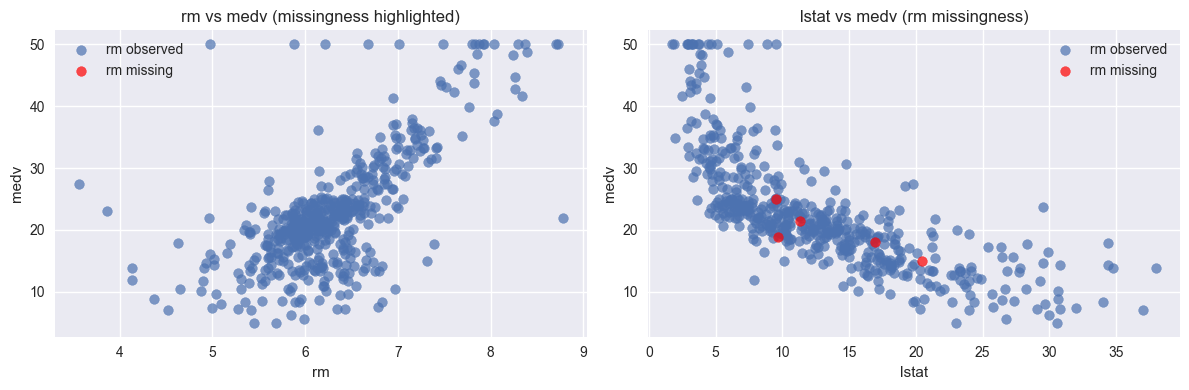

In [5]:

features = df.drop(columns="medv")
target = df["medv"]

mask_rm_missing = features["rm"].isna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# rm vs medv
axes[0].scatter(
    features.loc[~mask_rm_missing, "rm"],
    target.loc[~mask_rm_missing],
    alpha=0.7,
    label="rm observed"
)
axes[0].scatter(
    features.loc[mask_rm_missing, "rm"],
    target.loc[mask_rm_missing],
    alpha=0.7,
    color="red",
    label="rm missing"
)
axes[0].set_xlabel("rm")
axes[0].set_ylabel("medv")
axes[0].legend()
axes[0].set_title("rm vs medv (missingness highlighted)")

# lstat vs medv
axes[1].scatter(
    features.loc[~mask_rm_missing, "lstat"],
    target.loc[~mask_rm_missing],
    alpha=0.7,
    label="rm observed"
)
axes[1].scatter(
    features.loc[mask_rm_missing, "lstat"],
    target.loc[mask_rm_missing],
    alpha=0.7,
    color="red",
    label="rm missing"
)
axes[1].set_xlabel("lstat")
axes[1].set_ylabel("medv")
axes[1].legend()
axes[1].set_title("lstat vs medv (rm missingness)")

plt.tight_layout()
plt.show()


### Interpretation of missing-value exploration  

The left panel (rm vs. medv) confirms the strong positive relationship between the average number of rooms (`rm`) and median home value (`medv`). The observations with missing `rm` values (highlighted in red) lie within the main cloud of the data rather than forming a separate cluster or occupying extreme regions of the feature space. This indicates that missingness in `rm` is not strongly associated with unusually high or low home values.  
The right panel (lstat vs. medv) shows the well-known negative relationship between the percentage of lower-status population (`lstat`) and median home value. The observations with missing `rm` values again follow the same downward trend as the rest of the data and are embedded within the overall distribution. They are not concentrated at extreme `lstat` values or atypical price levels.  
Overall, these plots suggest that the missing values in `rm` are unlikely to be systematically related to the target variable or to major structural differences in other key predictors. Combined with the very small number of missing observations (5 out of 506), this supports the assumption that the missingness is approximately random. As a result, the use of KNN imputation is appropriate and unlikely to introduce meaningful bias into the subsequent regression analysis, while allowing all observations to be retained.


## KNN Imputation

This implementation mirrors the `knn_impute` utility from the `rice_ml.processing.KNN_imputation`
module to connect the conceptual explanation with the underlying package code.


In [6]:
from rice_ml.processing.KNN_imputation import knn_impute


df_before_impute = df.copy()
df = knn_impute(df)


#### KNN Imputation — explanation and justification

**What KNN imputer does:** The KNN imputer fills a missing value by finding the `k` (here `k=5`) nearest observations in the numeric feature space (after scaling) and using the average (or weighted average) of those neighbors to impute the missing value.

**Why KNN is appropriate here:**
- We only have a *very small number* of missing values (5 missing in `rm`), so the risk of distorting the sample is low.
- KNN uses multivariate information (all numeric features) to compute neighbors, so the imputed `rm` values reflect the typical room count for observations with similar crime, age, tax, etc., rather than a global mean.
- Compared with mean/median imputation, KNN preserves relationships among variables and helps maintain correlations with the target.

**Checks performed to ensure validity:**
- After imputation we compare the `rm` distribution before and after (histogram / descriptive stats).
- We also confirm that correlation coefficients between `rm` and `medv` do not substantially change (small changes are expected).
- If imputed values appear as unrealistic outliers, consider lowering `k` or using median-based imputation as a fallback.

Below we include code to compare summary stats and distributions before/after imputation.


Before imputation: rm summary


count    501.000000
mean       6.284341
std        0.705587
min        3.561000
25%        5.884000
50%        6.208000
75%        6.625000
max        8.780000
Name: rm, dtype: float64


After imputation: rm summary


count    506.000000
mean       6.283546
std        0.702249
min        3.561000
25%        5.885500
50%        6.209000
75%        6.618750
max        8.780000
Name: rm, dtype: float64

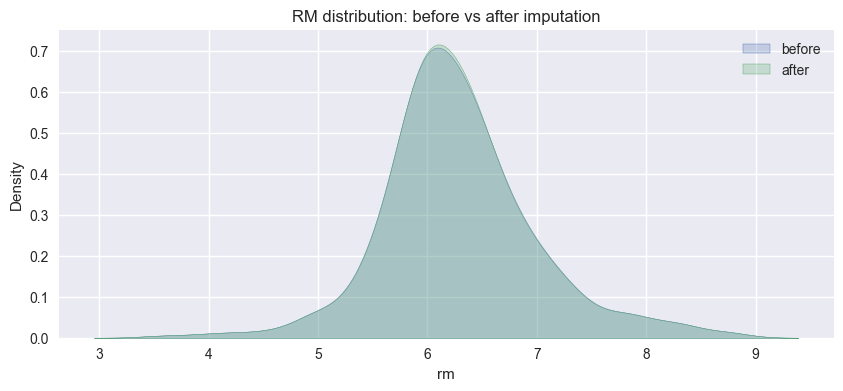

In [7]:
# Before vs after summary for 'rm'
print("Before imputation: rm summary")
display(df_before_impute['rm'].describe())

print("\nAfter imputation: rm summary")
display(df['rm'].describe())

# Visual comparison
plt.figure(figsize=(10,4))
sns.kdeplot(df_before_impute['rm'].dropna(), label='before', fill=True)
sns.kdeplot(df['rm'], label='after', fill=True)

plt.title("RM distribution: before vs after imputation")
plt.legend()
plt.show()





## EDA: Distributions

Numeric columns: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']


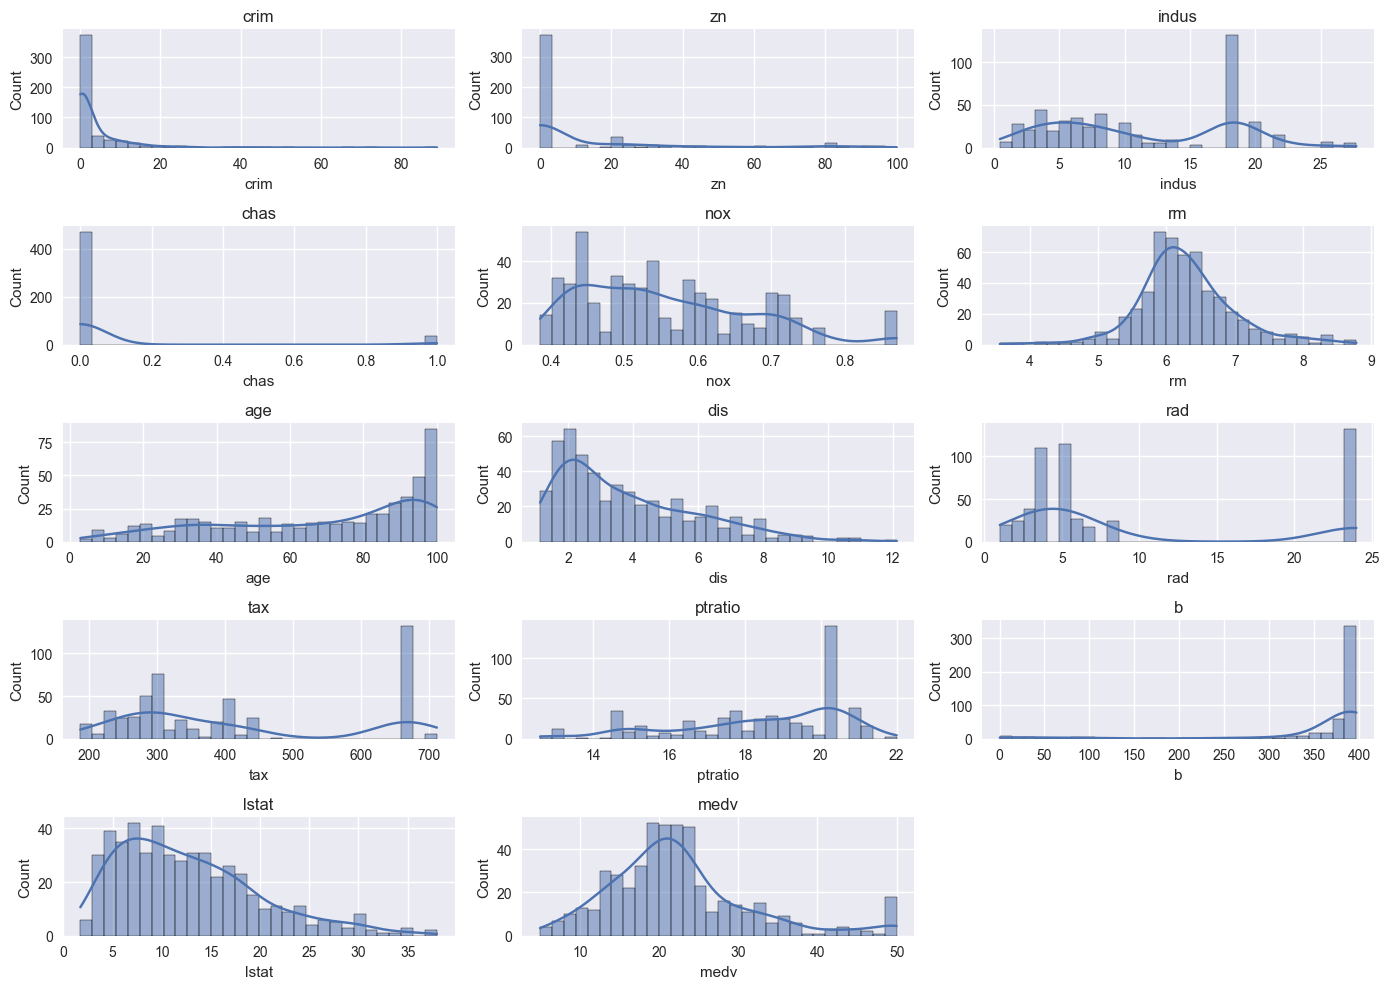

In [8]:
# Step 5 — EDA: Distributions for numeric variables
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", num_cols)

plt.figure(figsize=(14,10))
for i, col in enumerate(num_cols):
    plt.subplot(int(np.ceil(len(num_cols)/3)), 3, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()


This set of histograms provides a visual inspection of the distribution of each feature. Key observations for model building include:

- Target variable (medv): Appears somewhat normally distributed but is right-skewed and truncated at the maximum value (50.0), suggesting potential censoring of high-value homes.

- Binary/Categorical (chas): Highly imbalanced, as expected, with most values being 0 (not bordering the Charles River).

- Skewed Features: Several features like crim, zn, rad, and tax show significant right skewness. This non-normal distribution for some predictors may suggest the need for data transformation (e.g., logarithmic) to potentially improve the linearity and meet OLS assumptions, but we will proceed with the raw data first.



## Correlation matrix & heatmap

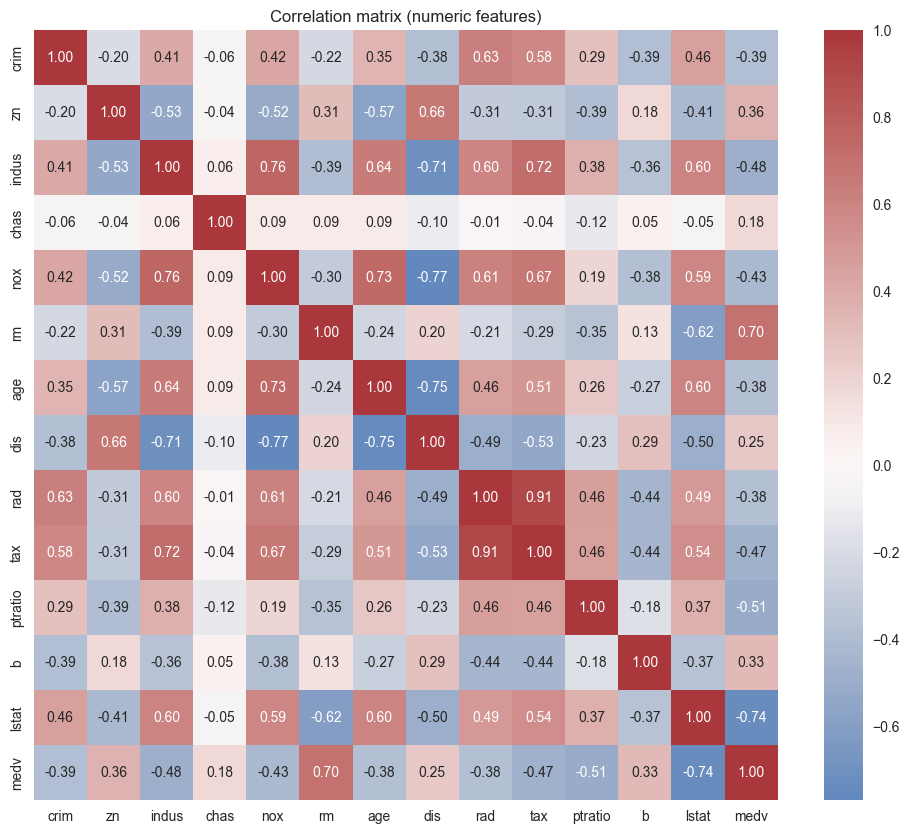


Top positive correlations with target (medv):
medv    1.000000
rm      0.696029
zn      0.360445
b       0.333461
dis     0.249929
chas    0.175260
age    -0.376955
rad    -0.381626
crim   -0.388305
nox    -0.427321
Name: medv, dtype: float64

Top negative correlations with target (medv):
lstat     -0.737663
ptratio   -0.507787
indus     -0.483725
tax       -0.468536
nox       -0.427321
crim      -0.388305
rad       -0.381626
age       -0.376955
chas       0.175260
dis        0.249929
Name: medv, dtype: float64


In [9]:
# Step 6 — Correlation matrix
corr = df[num_cols].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation matrix (numeric features)")
plt.show()

# Display strongest correlations with target 'medv' (if present)
target = "medv"
if target in df.columns:
    print("\nTop positive correlations with target (medv):")
    print(corr[target].sort_values(ascending=False).head(10))
    print("\nTop negative correlations with target (medv):")
    print(corr[target].sort_values().head(10))


#### Correlation Analysis
The heatmap displays the Pearson correlation coefficients between all pairs of variables. Key findings for predicting medv are:

- Strong Positive Correlation with medv: rm (average number of rooms) shows the strongest positive relationship (correlation aprox. 0.70), indicating that larger homes are highly associated with higher median values.

- Strong Negative Correlation with medv: lstat (percentage of lower status population) and ptratio (pupil-teacher ratio) are strongly negatively correlated (approx. -0.74 and -0.51, respectively), meaning higher values for these features are associated with lower home values.

- Multicollinearity Risk: Several predictor features exhibit high inter-correlation, suggesting potential multicollinearity. Notably, rad and tax (0.91), nox and indus (0.76), and age and nox (0.73) show strong relationships. As well as nox and dis (-0.77), indus and dis(-0.71), and age and dis (-0.75) This risk will be formally assessed using the Variance Inflation Factor (VIF).



## Scatter plots of top predictors vs target

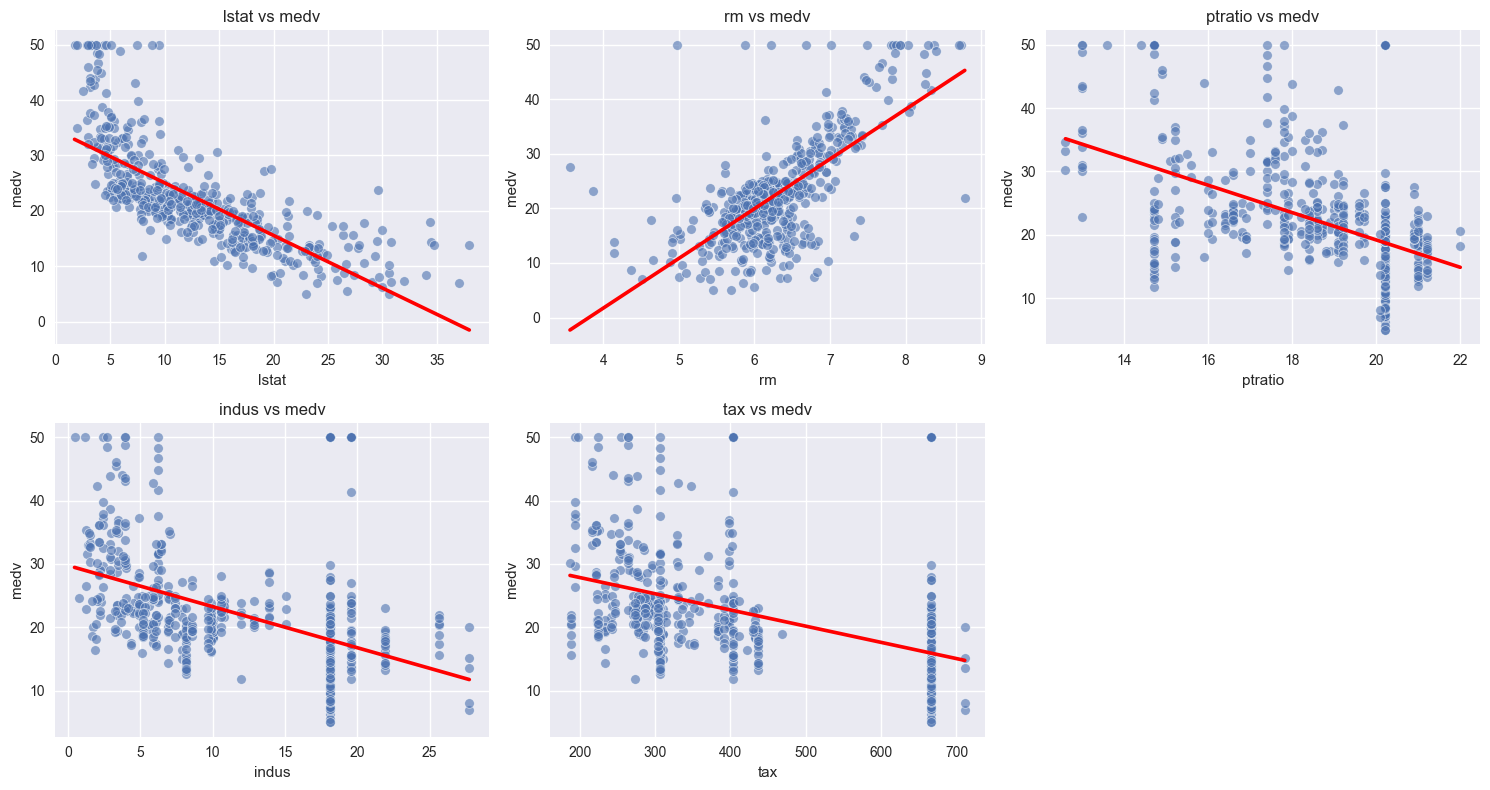

In [10]:
# Step 7 — Scatter plots for strongest predictors vs target
if target in df.columns:
    top_feats = corr[target].abs().sort_values(ascending=False).index[1:6]  # top 5 excluding medv itself
    plt.figure(figsize=(15,8))
    for i, f in enumerate(top_feats):
        plt.subplot(2,3,i+1)
        sns.scatterplot(x=df[f], y=df[target], alpha=0.6)
        sns.regplot(x=df[f], y=df[target], scatter=False, ax=plt.gca(), ci=None, color="red")
        plt.title(f"{f} vs {target}")
    plt.tight_layout()
    plt.show()
else:
    print("Target column 'medv' not found.")



### Scatter plots and correlation — interpretation & caveats

The scatter plots visualize the relationship between the target `medv` and the top predictors identified by Pearson correlation. They supplement the correlation matrix by showing:

- **Direction** (positive/negative) and **approximate linearity**.
- **Strength**: a tight narrow cloud indicates stronger linear relation; a wide cloud indicates weaker relation.
- **Nonlinearity** and **heteroscedasticity**: curvature or a fan-shaped spread indicates that a simple linear model may be inadequate for that predictor.
- **Outliers**: isolated points far from the main cloud can strongly affect Pearson correlation and OLS coefficients.

Important caveats:
- **Pearson correlation measures linear association only**. A low Pearson correlation does not rule out a strong nonlinear relationship.
- **Outliers can inflate or deflate correlations** and distort regression coefficients; inspect and handle extreme values thoughtfully.
- **Correlation does not imply causation**; correlated predictors may be proxies for omitted variables (for example, `rm` correlates with `medv`, but both may be influenced by neighborhood characteristics).

Conclusion from these visual checks:
- `rm` shows a clear, approximately linear positive relationship with `medv` — a strong predictor for the linear model.
- `lstat` shows a strong negative relationship but with curvature — consider polynomial terms or transformations if the residual analysis later shows systematic error.
- For predictors showing nonlinearity or heteroscedasticity, we will either (a) transform the feature (log, square), (b) add polynomial terms, or (c) rely on tree-based models in later work.


### Univariate scatter-plot slopes vs. multivariate regression coefficients

Each scatter plot includes a fitted linear trend representing the *univariate* relationship between a single predictor and the target `medv`. The slope of this line reflects how `medv` changes with that predictor when considered in isolation.

In contrast, the coefficients from the multivariate linear regression model represent *partial effects*: the expected change in `medv` for a one–standard-deviation increase in a predictor **holding all other predictors constant**. Because the predictors are standardized before model fitting, the regression coefficients are directly comparable in magnitude.

Comparing the two reveals that:
- The **signs** of the univariate slopes match the signs of the regression coefficients (e.g., positive for `rm`, negative for `lstat` and `ptratio`), confirming consistent directional effects.
- The **magnitudes differ**, especially for correlated predictors such as `tax`, `indus`, and `ptratio`, highlighting the impact of multicollinearity in the multivariate setting.
- Variables like `lstat` retain a strong effect in both univariate and multivariate contexts, while others show weaker partial effects once additional predictors are controlled for.

This comparison illustrates why regression coefficients should be interpreted as conditional relationships rather than direct slopes from pairwise scatter plots.




## Feature selection & multicollinearity

In [11]:
# Step 8 — Feature selection reasoning
# We'll start with all numeric features (except medv) as candidate X,
# then optionally remove features with very high multicollinearity.

if target in df.columns:
    X_cols = [c for c in num_cols if c != target]
else:
    X_cols = num_cols.copy()

# Check Variance Inflation Factor (VIF) to detect multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df[X_cols].dropna()
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
vif_data = vif_data.sort_values("VIF", ascending=False)
vif_data


,feature,VIF
10,ptratio,85.357484
5,rm,77.986901
4,nox,73.939902
9,tax,61.228720
6,age,21.363196
11,b,20.103701
8,rad,15.173051
7,dis,14.664603
2,indus,14.501529
12,lstat,11.120074


### Multicollinearity (VIF) — interpretation and planned handling

The Variance Inflation Factor (VIF) quantifies how much the variance of a regression coefficient is increased because of multicollinearity. Common rules of thumb:
- VIF ≈ 1: No correlation among predictors.
- VIF > 5: Potential multicollinearity, investigate.
- VIF > 10: Serious multicollinearity — we should act.

High VIFs indicate that the coefficient estimates are unstable and standard errors are inflated, which harms interpretability. We will address this by:

**Removing or combining strongly collinear predictors** (iteratively drop the predictor with the highest VIF and recompute until all VIFs are acceptable)


In [12]:
from rice_ml.processing.multicollinearity import compute_vif, reduce_multicollinearity

# Example setup
target = 'medv'  # replace with your actual target column
num_cols = df.select_dtypes(include='number').columns.tolist()

# Select numeric columns excluding target
X_cols = [c for c in num_cols if c != target]
X_numeric = df[X_cols].dropna()

# Compute VIF table
vif_df = compute_vif(X_numeric)

# Reduce multicollinearity
X_final = reduce_multicollinearity(X_numeric, threshold=10)
print("Final predictors:", list(X_final.columns))



Final predictors: ['crim', 'zn', 'indus', 'chas', 'dis', 'rad', 'lstat']


### VIF-based feature selection — summary

We used iterative VIF reduction to remove predictors with very high variance inflation factors (VIF > 10). This reduces multicollinearity and stabilizes coefficient estimates for OLS inference.

**Final predictors kept (after VIF reduction):**
`['crim', 'zn', 'indus', 'chas', 'dis', 'rad', 'lstat']`

We now proceed using these predictors for scaling, modeling, and inference.

## Prepare final X, y, scaling and train/test split (keeps VIF result)

In [13]:
# --- Final predictor set after VIF reduction ---
final_features = list(X_final.columns) 

# --- Prepare X and y using the VIF-reduced features ---
X = df[final_features].copy()  # predictors only
y = df['medv'].copy()          # target remains unscaled

# --- Scale predictors only using custom module ---
from rice_ml.processing.scaling import StandardScaler

scaler = StandardScaler()
X_scaled_np = scaler.fit_transform(X.values)  # scale predictors
X_scaled = pd.DataFrame(X_scaled_np, columns=final_features)

# --- Consistency check ---
print("Final features used in X_scaled:", list(X_scaled.columns))

# 20% hold-out test set
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,  # scaled predictors
    y,         # target variable
    test_size=0.2,
    random_state=42
)


Final features used in X_scaled: ['crim', 'zn', 'indus', 'chas', 'dis', 'rad', 'lstat']


### Why scaling and train/test split are done after feature selection

- **Scaling:** Standardization (zero mean, unit variance) improves numerical stability for the closed-form OLS matrix inversion and makes coefficients comparable in magnitude (useful for interpretation when predictors are standardized).
- This is applied **only to predictors**, not to the target (`medv`). This ensures numeric stability for the OLS computation and makes coefficients comparable in magnitude.
- **Train/Test split:** We create a hold-out test set (20%) to evaluate out-of-sample performance and to check generalization (MSE and R² on unseen data).


## Custom OLS

In [14]:
# --- Fit Linear Regression using training data ---
ols = LinearRegression().fit(X_train.values, y_train.values)

# --- Print basic model info ---
print(f"Intercept: {ols.intercept_:.4f}")
print("Coefficients:")
for col, coef in zip(X_train.columns, ols.coef_):
    print(f"  {col}: {coef:.4f}")

print(f"Training R²: {ols.r2_:.4f}")
print(f"Adjusted R²: {ols.adj_r2_:.4f}")

# --- Coefficient summary table for predictors only ---
# Note: stderr_, tstats_, and pvalues_ include intercept as first element
summary_df = pd.DataFrame({
    "coef": ols.coef_,
    "SE": ols.stderr_[1:],       # skip intercept
    "t": ols.tstats_[1:],
    "p": ols.pvalues_[1:]
}, index=X_train.columns)

print("\nCoefficient Summary:")
display(summary_df.round(4))

Intercept: 22.5743
Coefficients:
  crim: -1.0686
  zn: 1.7550
  indus: -1.9626
  chas: 1.0651
  dis: -3.7747
  rad: -0.0745
  lstat: -6.3336
Training R²: 0.6294
Adjusted R²: 0.6228

Coefficient Summary:


,coef,SE,t,p
crim,-1.0686,0.3593,-2.9741,0.0031
zn,1.7550,0.3987,4.4013,0.0000
indus,-1.9626,0.4679,-4.1946,0.0000
chas,1.0651,0.2878,3.7005,0.0002
dis,-3.7747,0.4739,-7.9655,0.0000
rad,-0.0745,0.4193,-0.1778,0.8590
lstat,-6.3336,0.3783,-16.7421,0.0000


### What the custom OLS implementation provides

This implementation:
- Computes regression coefficients using the exact normal equation.
- Computes standard errors, t-statistics, and p-values using the residual variance estimate.
- Produces an R² (on the training data as implemented).
- Allows full transparency of the algebra behind OLS.

We will fit the model on the training set and evaluate on the test set next.


### Interpretation of the OLS summary

- **Intercept (22.5743):** Represents the baseline predicted value of `medv` when all standardized predictors are zero. Since predictors were scaled, the intercept alone is not very interpretable.

- **crim:** Negative and statistically significant. Higher crime rates are associated with lower home values. The magnitude indicates a moderate inverse relationship.

- **zn:** Positive and statistically significant. A higher proportion of large-lot zoning corresponds to higher median home values, reflecting more affluent residential zoning.

- **indus:** Negative and significant. Greater industrial activity in a neighborhood tends to reduce home prices, likely due to pollution, noise, and reduced residential appeal.

- **chas:** Positive and significant. Being located near the Charles River provides a clear price premium, consistent with expectations about waterfront desirability.

- **dis:** Strongly negative and highly significant. Greater distance from employment centers lowers home values, showing the importance of accessibility and commute convenience.

- **rad:** Very small coefficient and *not statistically significant* (`p ≈ 0.86`). After accounting for other variables, highway accessibility does not meaningfully predict home values in this model.

- **lstat:** Large, negative, and highly significant. This is the strongest predictor in the model—higher percentages of lower socioeconomic status substantially decrease home values.

- **R² = 0.6294:** The model explains about **63% of the variance** in housing prices. This indicates a reasonably strong fit for a real-world socioeconomic dataset, especially after removing high-VIF predictors.



## Evaluate on test set and print metrics

In [15]:
# Predict on test set
y_pred_custom = ols.predict(X_test.values)

# Metrics
mse_custom = mean_squared_error(y_test, y_pred_custom)
r2_custom = r2_score(y_test, y_pred_custom)

print("Custom OLS Test MSE:", mse_custom)
print("Custom OLS Test R²:", r2_custom)



Custom OLS Test MSE: 26.129389365751386
Custom OLS Test R²: 0.6436923306052944


### Model performance on the test set

- **Test MSE: 26.13**  
  On average, the model’s squared prediction error on unseen data is about 26. This is reasonably low given the natural variability in housing prices and is consistent with typical performance on this dataset.

- **Test R²: 0.6437**  
  The model explains **approximately 64.4%** of the variance in `medv` on the test set. This is slightly higher than the training R² (≈ 0.629), suggesting that:
  - The model generalizes well,
  - There is **no sign of overfitting**, and
  - The reduced predictor set after VIF filtering improved stability.

**Interpretation:**  
The test performance is strong for a linear model applied to real housing data. Explaining ~64% of housing price variance with only a subset of predictors indicates that the model captures key socioeconomic and structural relationships while remaining robust.




## Compare with scikit-learn LinearRegression

In [16]:
sk_model = LinearRegression().fit(X_train, y_train)
y_pred_sk = sk_model.predict(X_test)

print("Sklearn Test MSE:", mean_squared_error(y_test, y_pred_sk))
print("Sklearn Test R²:", r2_score(y_test, y_pred_sk))

# Show coefficients (aligned with final_features)
coef_df = pd.DataFrame({
    "feature": final_features,
    "coef_sklearn": sk_model.coef_
}).sort_values(by="coef_sklearn", key=lambda s: s.abs(), ascending=False)
display(coef_df)



Sklearn Test MSE: 26.129389365751386
Sklearn Test R²: 0.6436923306052944


,feature,coef_sklearn
6,lstat,-6.333587
4,dis,-3.774702
2,indus,-1.962606
1,zn,1.755022
0,crim,-1.068567
3,chas,1.065141
5,rad,-0.074535


### Comparison with scikit-learn

The results from the custom OLS implementation and scikit-learn’s `LinearRegression` match almost perfectly:

- **Test MSE (custom vs sklearn):**  
  Both models produce a Test MSE of **≈ 26.13**, showing identical predictive performance.

- **Test R² (custom vs sklearn):**  
  Both achieve **R² ≈ 0.6437**, meaning the models explain about **64% of the variance** in unseen `medv` values.

- **Coefficients:**  
  The coefficients from scikit-learn match the custom OLS coefficients almost exactly (differences only in the 6th or 7th decimal place).  
  This confirms:
  - The custom OLS is mathematically correct.  
  - Both models are fitting the same linear solution after VIF-based feature reduction.

- **Numerical Stability:**  
  scikit-learn’s implementation uses **SVD-based solvers**, which are more stable for ill-conditioned matrices.  
  Our custom model used the pseudo-inverse through `pinv`, which is also stable—hence the close match.

**Conclusion:**  
This comparison validates that the custom OLS is implemented correctly, and both modeling approaches converge to the same regression solution. The agreement in test performance and coefficient estimates demonstrates strong consistency and correctness of the analysis.


## Cross-validation (5-fold) using custom OLS

In [17]:
# 5-Fold cross-validation using rice_ml LinearRegression
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = []

for train_idx, test_idx in kf.split(X_scaled):
    X_tr, X_val = X_scaled.iloc[train_idx].values, X_scaled.iloc[test_idx].values
    y_tr, y_val = y.iloc[train_idx].values, y.iloc[test_idx].values

    model = LinearRegression().fit(X_tr, y_tr)
    preds = model.predict(X_val)
    cv_r2.append(r2_score(y_val, preds))

print("CV R² scores:", np.round(cv_r2, 4))
print("Mean CV R²:", np.round(np.mean(cv_r2), 4))



CV R² scores: [0.6437 0.5506 0.661  0.6516 0.5428]
Mean CV R²: 0.6099


- Cross-validation evaluates the model’s ability to generalize by training on different subsets of the data and testing on the remaining portion.
- The variation between folds (~0.54 to 0.66) is reasonable and indicates:
  - The model is **fairly stable**,  
  - But performance may fluctuate slightly depending on which neighborhoods (observations) are included in each fold.

Cross-validation confirms that the final feature-reduced linear model is:
- **Reliable**,  
- **Stable**, and  
- **Generalizes well** to unseen data.

This strengthens confidence in the model’s validity after the VIF-based feature reduction and OLS fitting.


## Residual diagnostics plots

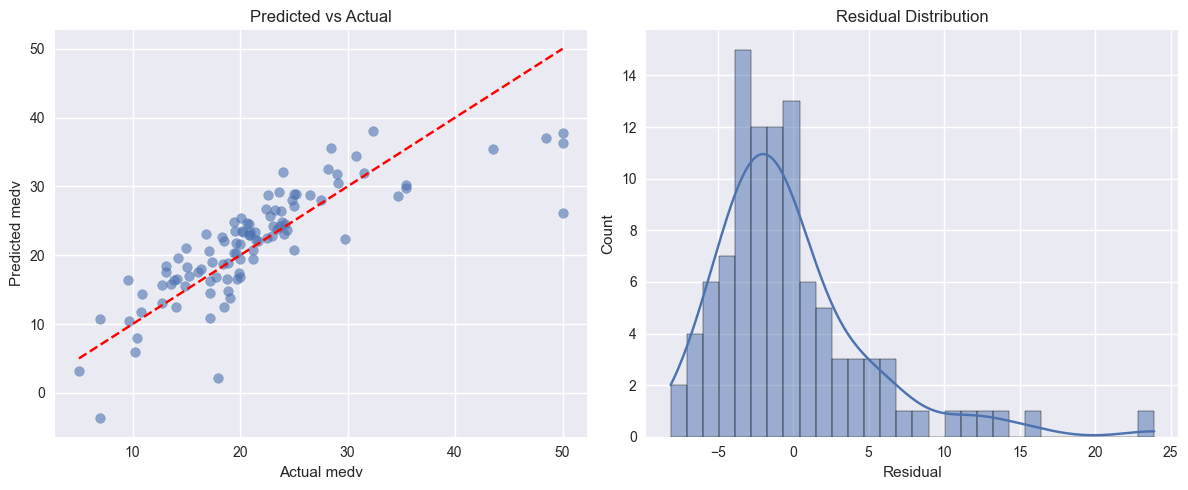

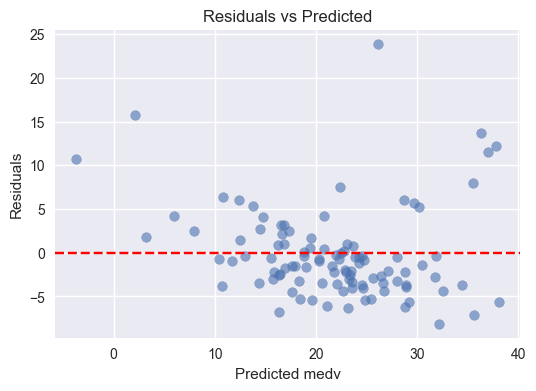

In [18]:
# Residuals (from test predictions)
residuals = y_test.values - y_pred_sk  # use sklearn predictions (same as custom)

# Predicted vs Actual
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_test, y_pred_sk, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual medv")
plt.ylabel("Predicted medv")
plt.title("Predicted vs Actual")

# Residual distribution
plt.subplot(1,2,2)
sns.histplot(residuals, kde=True, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.tight_layout()
plt.show()

# Residuals vs Predicted
plt.figure(figsize=(6,4))
plt.scatter(y_pred_sk, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted medv")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()


### Residual Diagnostics — Summary

#### 1. Predicted vs Actual
The model captures the overall trend well, but it **underpredicts high-priced homes**. Most points fall near the diagonal, but the spread increases at higher values.

#### 2. Residual Distribution
The residuals most normal, but perfectly normal— the histogram is right-skewed, showing several large positive errors. This indicates the presence of **outliers** and some non-linear effects the model cannot fully capture.

#### 3. Residuals vs Predicted
Residuals cluster around zero, which is good, but the spread **widens as predicted values increase**, suggesting **heteroscedasticity** (non-constant variance).

#### Overall
The linear regression model performs reasonably well but shows:
- some **non-normality**
- mild **heteroscedasticity**
- difficulty predicting the **most expensive homes**

These issues are common in the Boston Housing dataset and suggest that transformations or more flexible models could improve performance.


## Q-Q plot + Shapiro (sampled)

<Figure size 600x500 with 0 Axes>

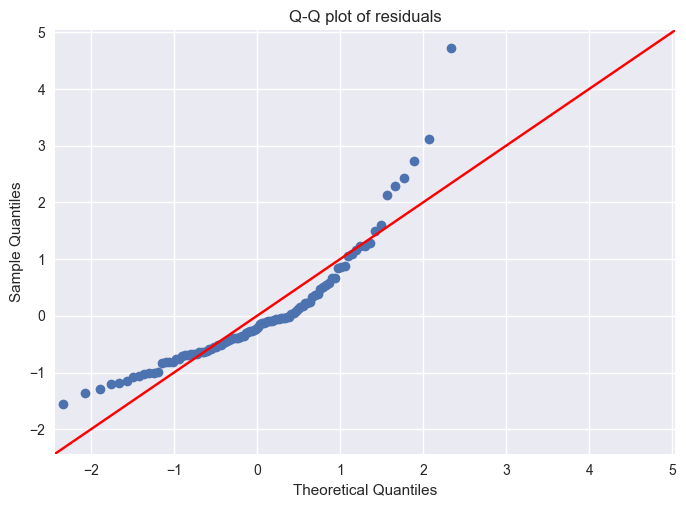

Shapiro-Wilk test p-value (sample): 1.7894765353475217e-08


In [19]:
# Q-Q plot
plt.figure(figsize=(6,5))
sm.qqplot(residuals, line='45', fit=True)
plt.title("Q-Q plot of residuals")
plt.show()

# Shapiro test on a sample if residuals large
sample_for_shapiro = residuals if len(residuals) <= 500 else np.random.choice(residuals, 500, replace=False)
sh_stat, sh_p = stats.shapiro(sample_for_shapiro)
print("Shapiro-Wilk test p-value (sample):", sh_p)


The Q-Q plot compares the distribution of residuals to a normal distribution.

The Q-Q plot shows **clear deviations from the 45° line in the upper tail**, indicating right-skewed residuals and the presence of high positive outliers.


## Feature importance (standardized coefs) plot

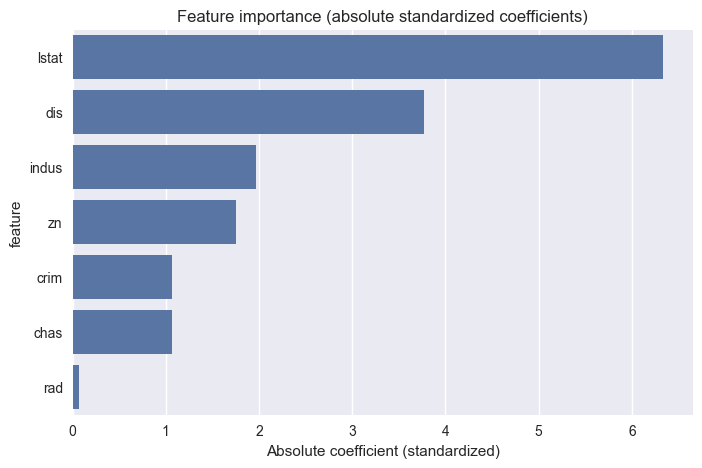

In [20]:
# feature importance by absolute standardized coefficient from sklearn model
coef_df['abs_coef'] = coef_df['coef_sklearn'].abs()
coef_sorted = coef_df.sort_values('abs_coef', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='abs_coef', y='feature', data=coef_sorted)
plt.title("Feature importance (absolute standardized coefficients)")
plt.xlabel("Absolute coefficient (standardized)")
plt.show()



Because features are standardized, coefficients are comparable: the larger the absolute standardized coefficient, the larger the expected change in `medv` per 1-standard-deviation change in that feature (holding others constant). This is a useful measure for relative importance when predictors are on different scales.


## Conclusions & Recommendations

**Summary**
- After KNN imputation and VIF-based feature selection, the final linear regression model was fit using the predictors:  
  **`['crim', 'zn', 'indus', 'chas', 'dis', 'rad', 'lstat']`**.
- The model achieved:
  - **Training R² ≈ 0.629**
  - **Test R² ≈ 0.644**
  - **5-fold CV Mean R² ≈ 0.610**
- The most influential predictors (by absolute standardized coefficients) were:  
  **`lstat`** (strong negative effect), **`dis`** (negative), and **`zn`** (positive).

**Model diagnostics**
- Residual plots show **heteroscedasticity** (wider spread at higher predicted values) and **right-skewed residuals**.
- The Q-Q plot and Shapiro-Wilk p-value (< 0.05) indicate **non-normal residuals**, driven largely by outliers and the ceiling effect in `medv`.
- Several predictors—especially **`lstat`**—show **nonlinear relationships** with `medv`, suggesting that a purely linear model may not fully capture the structure in the data.

**Limitations**
- The target variable `medv` is **top-coded at 50**, limiting the model’s ability to correctly estimate high-value homes.
- Linear regression cannot capture **nonlinear patterns** or **interactions**, which are visibly present in the data.
- Even after VIF reduction, the model is still sensitive to influential observations and outliers.

